In [1]:
#Import libraries
import os
import csv
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import matplotlib.pyplot as plt
import random as rand

from math import sin, cos, radians
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split


In [2]:
#Define coordTransform function
def coordTransform(img, center, radius, tireDepth, wheelDepth, scaleWidth, scaleHeight):
    #This function tranforms an image from cartesian to polar
    pixelPerDeg = scaleWidth / 360
    pixelPerRadWheel = wheelDepth / scaleHeight
    pixelPerRadTire = tireDepth / scaleHeight

    tireStrip = np.zeros((scaleHeight, scaleWidth, 3))
    wheelStrip = np.zeros((scaleHeight, scaleWidth, 3))

    for x in range(scaleWidth):
        angle = x / pixelPerDeg
        for y in range(scaleHeight):
            cartCoordXTire = int(((radius + (y * pixelPerRadTire)) * cos(radians(angle)))) + center[1]
            cartCoordYTire = int(((radius + (y * pixelPerRadTire)) * sin(radians(angle)))) + center[0]
            cartCoordXWheel = int(((radius - (y * pixelPerRadWheel)) * cos(radians(angle)))) + center[1]
            cartCoordYWheel = int(((radius - (y * pixelPerRadWheel)) * sin(radians(angle)))) + center[0]
            tireStrip[y][x] = img[cartCoordXTire][cartCoordYTire]
            wheelStrip[y][x] = img[cartCoordXWheel][cartCoordYWheel]
            
    return tireStrip.astype(np.uint8), wheelStrip.astype(np.uint8)

In [3]:
#Import data
root = "C:\\Users\\dsher\\OneDrive\\Documents\\School\\2026 Winter\\CSI 4130\\Final Project\\ImagesSorted\\GoodImages"
counter = 0
xData = []
yData = []

for name in sorted(os.listdir(root)):
    with Image.open(root + "\\" + name) as img:
        xData.append([np.array(img)])

with open('DataGood.csv', 'r') as file:
    csvReader = csv.reader(file)
    for row in csvReader:
        yData.append(float(row[13]))
        xData[counter].append([row[0], row[1], int(row[10]), int(row[11]), int(row[12])])
        counter += 1


In [4]:
#Define some variables
ModCode = 0
Sequence = 1
Radius = 2
TireDepth = 3
WheelDepth = 4
center = (1217, 975)
widthScale = 720
heightScale = 40
trainSize = 0.90
epochs = 40


In [5]:
#Preprocess
for i in range(len(xData)):
    xData[i][0] = coordTransform(xData[i][0], center, xData[i][1][Radius], xData[i][1][TireDepth], xData[i][1][WheelDepth], widthScale, heightScale)
    

In [6]:
#Split dataset
imageData = xData#[row[0] for row in xData]

xTrain, xTest, yTrain, yTest = train_test_split(imageData, yData, train_size=trainSize, shuffle= True)

(40, 720, 3)


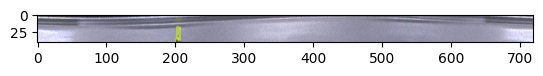

In [7]:
#Show image for testing
temp = xData[1][0][1]
print(temp.shape)
plt.imshow(temp)

In [8]:
#Define transformers
trainTransforms = T.Compose([

    #T.Resize((heightScale, widthScale)),

    T.ColorJitter(
        brightness= 0.1,
        contrast= 0.15
    ),

    T.ToTensor(),

    T.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

valTransforms = T.Compose([
    #T.Resize((heightScale, widthScale)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [9]:
#Define AngleDataset class
class AngleDataset(Dataset):

    def __init__(self, xData, yData, transform=None):
        self.xData = xData
        self.yData = yData
        self.transform = transform

    def __len__(self):
        return len(self.yData)
    
    def __getitem__(self, idx):

        imgTire, imgWheel = self.xData[idx][0]
        sequence = self.xData[idx][1][1]
        angle = self.yData[idx]

        if isinstance(imgTire, np.ndarray):
            imgTire = Image.fromarray(imgTire)

        if isinstance(imgWheel, np.ndarray):
            imgWheel = Image.fromarray(imgWheel)

        if self.transform:
            seed = np.random.randint(0, 1_000_000)

            rand.seed(seed)
            torch.manual_seed(seed)
            imgTire = self.transform(imgTire)

            rand.seed(seed)
            torch.manual_seed(seed)
            imgWheel = self.transform(imgWheel)

        angle = torch.tensor(
            angle, 
            dtype= torch.float32
        )

        return imgTire, imgWheel, angle, sequence


In [10]:
#Define datasets
trainDataset = AngleDataset(
    xTrain,
    yTrain,
    transform= trainTransforms
)

valDataset = AngleDataset(
    xTest,
    yTest,
    transform= valTransforms
)

In [11]:
#Define dataloaders
trainLoader = DataLoader(
    trainDataset,
    batch_size= 16,
    shuffle= True
)

valLoader = DataLoader(
    valDataset,
    batch_size= 16,
    shuffle= False
)

In [12]:
#Define model
class TinyAngleModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            3, 8,
            kernel_size=(7, 7),
            padding=3
        )

        self.pool1 = nn.MaxPool2d((4, 2))

        self.conv2 = nn.Conv2d(
            8, 16,
            kernel_size=(5, 5),
            padding=2
        )

        self.pool2 = nn.MaxPool2d((2, 2))

        self.global_pool = nn.AdaptiveAvgPool2d((1, 32))

        self.fc1 = nn.Linear(16 * 32 * 2, 32)

        self.fc2 = nn.Linear(32, 2) 

    def forward(self, img1, img2):

        f1 = self.encode(img1)
        f2 = self.encode(img2)

        x = torch.cat([f1, f2], dim=1)

        x = F.relu(self.fc1(x))

        x = torch.tanh(self.fc2(x))
        
        return x

    def encode(self, x):

        x = F.relu(self.conv1(x))

        x = self.pool1(x)

        x = F.relu(self.conv2(x))

        x = self.pool2(x)

        x = self.global_pool(x)

        return x.view(x.size(0), -1)

In [13]:
#Instantiate model
model = TinyAngleModel()
device = torch.device("cpu")
model.to(device)

TinyAngleModel(
  (conv1): Conv2d(3, 8, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
  (pool1): MaxPool2d(kernel_size=(4, 2), stride=(4, 2), padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 32))
  (fc1): Linear(in_features=1024, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=2, bias=True)
)

In [14]:
#Define angleLoss function
def angleLoss(pred, targetDeg):

    target_rad = torch.deg2rad(targetDeg)

    target = torch.stack([
        torch.sin(target_rad),
        torch.cos(target_rad)
    ], dim=1)

    return F.mse_loss(pred, target)

In [15]:
#Define optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience= 5
)

In [16]:
#Define predictAngle function
def predictAngle(output):
    sinPred = output[:, 0]
    cosPred = output[:, 1]

    angleRad = torch.atan2(
        sinPred,
        cosPred
    )

    angleDeg = (
        torch.rad2deg(angleRad)
    )

    return angleDeg

In [17]:
#Define angularError function
def angularError(predDeg, trueDeg):

    diff = predDeg - trueDeg

    diff = (diff + 180) % 360 - 180

    return torch.abs(diff)

In [18]:
#Training loop
#epochs = 40

for epoch in range(epochs):

    model.train()

    trainLoss = 0

    for imgTire, imgWheel, angle, sequence in trainLoader:

        imgTire = imgTire.to(device)
        imgWheel = imgWheel.to(device)
        angle = angle.to(device)

        optimizer.zero_grad()

        pred = model(imgTire, imgWheel)

        loss = angleLoss(
            pred,
            angle
        )

        loss.backward()

        optimizer.step()

        trainLoss += loss.item()

    avgLoss = trainLoss / len(trainLoader)
        
    model.eval()

    totalError = 0
    numSamples = 0

    with torch.no_grad():

        for imgTire, imgWheel, angle, sequence in valLoader:

            imgTire = imgTire.to(device)
            imgWheel = imgWheel.to(device)
            angle = angle.to(device)

            output = model(
                imgTire,
                imgWheel
            )

            pred_angle = predictAngle(output)

            error = angularError(
                pred_angle,
                angle
            )

            totalError += error.sum().item()

            numSamples += len(angle)

    valError = totalError / numSamples

    trainTotalError = 0
    trainSamples = 0

    for imgTire, imgWheel, angle, sequence in trainLoader:

        imgTire = imgTire.to(device)
        imgWheel = imgWheel.to(device)
        angle = angle.to(device)

        output = model(imgTire, imgWheel)

        pred_angle = predictAngle(output)

        error = angularError(
            pred_angle,
            angle
        )

        trainTotalError += error.sum().item()
        trainSamples += len(angle)

    trainError = trainTotalError / trainSamples

    
    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {avgLoss:.4f} | "
        f"Train Error: {trainError:.2f} deg | "
        f"Val Error: {valError:.2f} deg"
    )

Epoch 1 | Train Loss: 0.4659 | Train Error: 68.67 deg | Val Error: 65.51 deg
Epoch 2 | Train Loss: 0.4534 | Train Error: 68.44 deg | Val Error: 65.41 deg
Epoch 3 | Train Loss: 0.4500 | Train Error: 68.36 deg | Val Error: 67.13 deg
Epoch 4 | Train Loss: 0.4403 | Train Error: 66.97 deg | Val Error: 65.14 deg
Epoch 5 | Train Loss: 0.4420 | Train Error: 66.90 deg | Val Error: 64.77 deg
Epoch 6 | Train Loss: 0.4384 | Train Error: 65.46 deg | Val Error: 65.65 deg
Epoch 7 | Train Loss: 0.4357 | Train Error: 66.26 deg | Val Error: 71.32 deg
Epoch 8 | Train Loss: 0.4288 | Train Error: 64.00 deg | Val Error: 65.37 deg
Epoch 9 | Train Loss: 0.4308 | Train Error: 63.01 deg | Val Error: 63.48 deg
Epoch 10 | Train Loss: 0.4248 | Train Error: 63.09 deg | Val Error: 62.47 deg
Epoch 11 | Train Loss: 0.4101 | Train Error: 61.75 deg | Val Error: 64.29 deg
Epoch 12 | Train Loss: 0.4030 | Train Error: 61.07 deg | Val Error: 62.30 deg
Epoch 13 | Train Loss: 0.3952 | Train Error: 57.94 deg | Val Error: 65.10

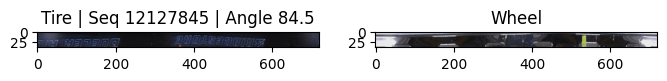

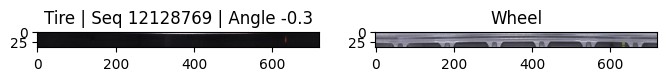

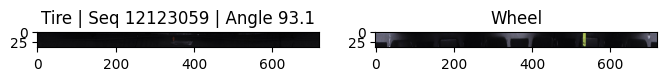

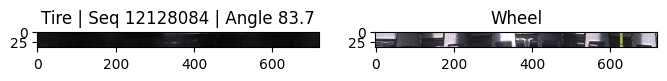

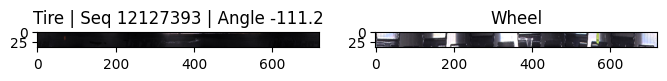

In [19]:
#Show images for data validation
for i in range(5):

    imgTire, imgWheel, angle, sequence = trainDataset[i]

    # Undo normalization
    imgTire = imgTire * 0.5 + 0.5
    imgWheel = imgWheel * 0.5 + 0.5

    imgTire = imgTire.permute(1, 2, 0).numpy()
    imgWheel = imgWheel.permute(1, 2, 0).numpy()

    plt.figure(figsize=(8,3))

    plt.subplot(1,2,1)
    plt.imshow(imgTire)
    plt.title(f"Tire | Seq {sequence} | Angle {angle.item():.1f}")

    plt.subplot(1,2,2)
    plt.imshow(imgWheel)
    plt.title("Wheel")

    plt.show()